# EDGAR v8.1 – NOₓ Emission Inventory – Jorf Lasfar Industrial Source

This notebook downloads **EDGARv8.1 gridded NOₓ emission inventory** data from the  
**JRC open-data FTP server** and performs:

1. **Global spatial map** – NOₓ total emissions for a selected year.
2. **Regional / city-scale maps** – zoom into Morocco, Casablanca metropolitan area, and the  
   Jorf Lasfar industrial complex (OCP phosphate plant + Jorf Lasfar Energy coal power station).
3. **Long-term time series** – annual NOₓ at the Jorf Lasfar grid cell (1970–2022), plus  
   a Morocco country-level total extracted from the same gridded dataset.

**Data source**: EDGAR v8.1 Air Pollutants (Crippa et al., 2024)  
Resolution: 0.1 ° × 0.1 °, units in gridded files: kg m⁻² s⁻¹  

#### Outline
1. [Imports & settings](#setup)
2. [Download gridded NOₓ (selected years)](#download)
3. [Global spatial map](#global)
4. [Regional / city-scale maps](#regional)
5. [Time series at Jorf Lasfar](#timeseries)
6. [Sector breakdown at Jorf Lasfar](#sectors)

In [1]:
# Install required packages (skip cells already in the environment)
!pip install xarray netCDF4 cartopy matplotlib numpy requests tqdm pandas

## <a id='setup'></a>1 – Imports & settings

In [2]:
import io
import os
import zipfile
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import requests
import xarray as xr
from tqdm import tqdm

# ── Directory layout ─────────────────────────────────────────────────────────
DATA_DIR = Path("data") / "EDGAR_NOx"
DATA_DIR.mkdir(parents=True, exist_ok=True)

# ── Point source: Jorf Lasfar industrial complex, Morocco ─────────────────────
JL_LON  = -8.638   # °E
JL_LAT  = 33.103   # °N
JL_NAME = "Jorf Lasfar"

# ── EDGAR v8.1 base URL ───────────────────────────────────────────────────────
EDGAR_BASE = (
    "https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/EDGAR/datasets"
    "/v81_FT2022_AP_new/NOx/TOTALS/emi_nc"
)

print("Setup complete.")
print(f"Data directory : {DATA_DIR.resolve()}")
print(f"Point source   : {JL_NAME}  lon={JL_LON}°E  lat={JL_LAT}°N")

Setup complete.
Data directory : /Users/farhan/Documents/um6p/pre-doc_courses/cwcc_training/satellite/wildfire_chemicals/data/EDGAR_NOx
Point source   : Jorf Lasfar  lon=-8.638°E  lat=33.103°N


## <a id='download'></a>2 – Download gridded NOₓ data

Each annual file is a zip archive (~15 MB) containing a single netCDF file.  
We download a representative set of years:
- **Snapshot years** for spatial maps: 1990, 2000, 2010, 2019, 2022
- **All years 1970–2022** for the time-series analysis

Already-downloaded files are skipped.

In [3]:
def edgar_nc_url(year: int) -> str:
    """Return the EDGAR v8.1 NOx total gridded netCDF zip URL for *year*."""
    fname = f"v8.1_FT2022_AP_NOx_{year}_TOTALS_emi_nc.zip"
    return f"{EDGAR_BASE}/{fname}"


def download_edgar_year(year: int, data_dir: Path = DATA_DIR) -> Path:
    """
    Download & unzip one year of EDGAR NOx gridded data.
    Returns the path to the extracted netCDF file.
    """
    nc_name = f"v8.1_FT2022_AP_NOx_{year}_TOTALS.0.1x0.1.nc"
    nc_path = data_dir / nc_name
    if nc_path.exists():
        return nc_path

    url = edgar_nc_url(year)
    print(f"  Downloading {year} … ", end="", flush=True)
    resp = requests.get(url, stream=True, timeout=120)
    resp.raise_for_status()

    total = int(resp.headers.get("content-length", 0))
    buf   = io.BytesIO()
    with tqdm(total=total, unit="B", unit_scale=True, leave=False) as pbar:
        for chunk in resp.iter_content(chunk_size=1 << 16):
            buf.write(chunk)
            pbar.update(len(chunk))

    buf.seek(0)
    with zipfile.ZipFile(buf) as zf:
        # The nc file inside may have a slightly different name – find it
        nc_members = [m for m in zf.namelist() if m.endswith(".nc")]
        if not nc_members:
            raise FileNotFoundError(f"No .nc file in zip for year {year}")
        zf.extract(nc_members[0], path=data_dir)
        extracted = data_dir / nc_members[0]
        # Rename to a consistent pattern if needed
        if extracted != nc_path:
            extracted.rename(nc_path)

    print("done.")
    return nc_path


# ── Years to download ─────────────────────────────────────────────────────────
SNAP_YEARS  = [1990, 2000, 2010, 2019, 2022]   # for maps
ALL_YEARS   = list(range(1970, 2023))           # for time series

print("Downloading snapshot years for maps …")
snap_paths = {yr: download_edgar_year(yr) for yr in SNAP_YEARS}
print("\nSnapshot downloads complete.")

done.

done.

done.

done.

done.

Snapshot downloads complete.


In [4]:
# Download all years for the time-series (this may take several minutes on first run)
print("Downloading all years 1970–2022 for time-series analysis …")
all_paths = {yr: download_edgar_year(yr) for yr in ALL_YEARS}
print(f"\nAll {len(all_paths)} year-files ready.")

done.

done.

done.

done.

done.

...

done.

done.

done.

done.

done.

All 53 year-files ready.


## Helper: open one year's netCDF and inspect

In [5]:
def open_edgar_nc(path: Path) -> xr.Dataset:
    """Open EDGAR netCDF, normalising coordinate names."""
    ds = xr.open_dataset(path)
    # EDGAR uses 'lat'/'lon' or 'latitude'/'longitude' depending on the release
    rename_map = {}
    for old, new in [("latitude", "lat"), ("longitude", "lon")]:
        if old in ds.coords and new not in ds.coords:
            rename_map[old] = new
    if rename_map:
        ds = ds.rename(rename_map)
    return ds


# Inspect the 2022 file
ds2022 = open_edgar_nc(snap_paths[2022])
print(ds2022)
print()
# Main emission variable (kg m-2 s-1)
emi_var = [v for v in ds2022.data_vars if "emi" in v.lower() or "nox" in v.lower()][0]
print(f"Emission variable : '{emi_var}'")
print(f"Units             : {ds2022[emi_var].attrs.get('units', 'unknown')}")
print(f"Shape             : {ds2022[emi_var].shape}")
print(f"Lat range         : {float(ds2022.lat.min()):.1f} – {float(ds2022.lat.max()):.1f}")
print(f"Lon range         : {float(ds2022.lon.min()):.1f} – {float(ds2022.lon.max()):.1f}")

<xarray.Dataset> Size: 26MB
Dimensions:    (lat: 1800, lon: 3600)
Coordinates:
  * lat        (lat) float64 14kB -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
  * lon        (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.8 179.9
Data variables:
    emissions  (lat, lon) float32 26MB ...
Attributes:
    institution:       European Commission, Joint Research Centre
    source:            https://edgar.jrc.ec.europa.eu/dataset_ap81
    how_to_cite:       https://edgar.jrc.ec.europa.eu/dataset_ap81#howtocite
    copyright_notice:  https://edgar.jrc.ec.europa.eu/dataset_ap81#conditions
    contacts:          https://edgar.jrc.ec.europa.eu/dataset_ap81#info JRC-E...

Emission variable : 'emissions'
Units             : Tonnes
Shape             : (1800, 3600)
Lat range         : -90.0 – 90.0
Lon range         : -179.9 – 179.9


In [6]:
# ── Unit conversion helpers ────────────────────────────────────────────────────
# EDGAR gridded files store flux in kg(species) m⁻² s⁻¹
# To convert to Mg (tonne) yr⁻¹ per grid cell:
#   mass [kg/yr] = flux [kg/m²/s] × cell_area [m²] × seconds_per_year

SECS_PER_YEAR = 365.25 * 24 * 3600


def cell_area_m2(lat: np.ndarray, dlat: float = 0.1, dlon: float = 0.1) -> np.ndarray:
    """
    Approximate area [m²] of a 0.1° × 0.1° grid cell at each latitude.
    lat : 1-D array of centre latitudes (degrees).
    """
    R = 6_371_000.0  # Earth radius, m
    lat_rad = np.deg2rad(lat)
    dy = np.deg2rad(dlat) * R
    dx = np.deg2rad(dlon) * R * np.cos(lat_rad)
    return dy * dx   # shape (nlat,)


def flux_to_Tg_per_year(flux_kg_m2_s: xr.DataArray) -> xr.DataArray:
    """
    Convert EDGAR flux [kg m⁻² s⁻¹] to emission mass [Tg yr⁻¹] per grid cell.
    """
    lats = flux_kg_m2_s.lat.values          # (nlat,)
    area = cell_area_m2(lats)               # (nlat,)
    # Broadcast area to (nlat, nlon)
    area_2d = area[:, np.newaxis]
    mass_kg_yr = flux_kg_m2_s.values * area_2d * SECS_PER_YEAR
    mass_Tg_yr = mass_kg_yr / 1e9           # 1 Tg = 1e9 kg
    return xr.DataArray(
        mass_Tg_yr,
        coords=flux_kg_m2_s.coords,
        dims=flux_kg_m2_s.dims,
        attrs={"units": "Tg NOx yr-1", "long_name": "NOx emission"},
    )


print("Unit-conversion helpers defined.")

Unit-conversion helpers defined.


## <a id='global'></a>3 – Global spatial map of NOₓ emissions

We plot the 2022 annual total NOₓ emission on a global map (log-scale colour bar)  
and mark the location of Jorf Lasfar.

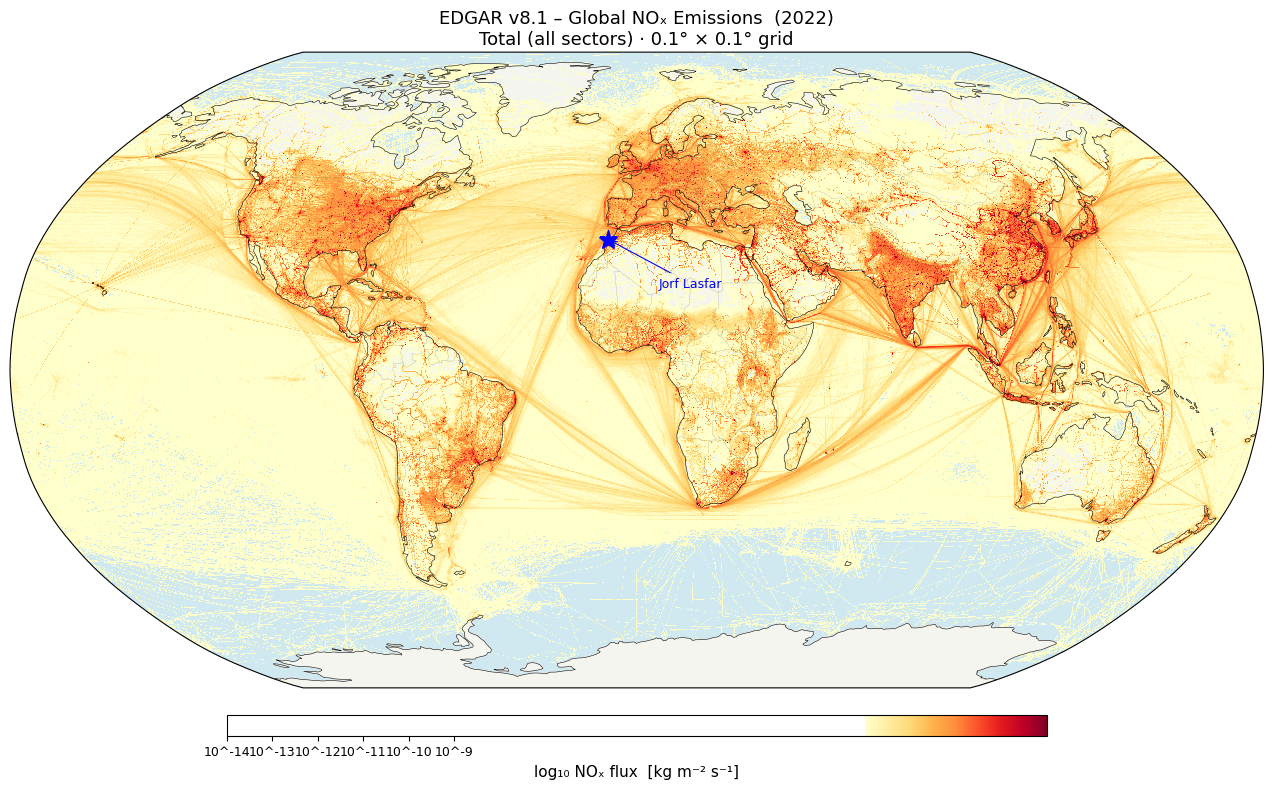

In [15]:
def plot_global_nox(
    ds: xr.Dataset,
    year: int,
    point_lon: float = JL_LON,
    point_lat: float = JL_LAT,
    point_name: str = JL_NAME,
):
    """Global map of NOₓ flux (log scale)."""
    emi_var = [v for v in ds.data_vars if "emi" in v.lower() or "nox" in v.lower()][0]
    flux = ds[emi_var].squeeze()   # remove time dim if present

    # Convert to log₁₀, masking zeros
    flux_vals = flux.values.astype(float)
    flux_vals[flux_vals <= 0] = np.nan
    log_flux = np.log10(flux_vals)

    fig, ax = plt.subplots(
        figsize=(16, 8),
        subplot_kw={"projection": ccrs.Robinson()},
    )
    ax.set_global()
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.2, linestyle=":")
    ax.add_feature(cfeature.OCEAN,     color="#d0e8f0", zorder=0)
    ax.add_feature(cfeature.LAND,      color="#f5f5f0", zorder=0)

    mesh = ax.pcolormesh(
        ds.lon.values,
        ds.lat.values,
        log_flux,
        transform=ccrs.PlateCarree(),
        cmap="YlOrRd",
        vmin=-0,
        vmax=4,
        shading="auto",
    )
    cbar = fig.colorbar(mesh, ax=ax, orientation="horizontal",
                        fraction=0.03, pad=0.04, aspect=40)
    cbar.set_label("log₁₀ NOₓ flux  [kg m⁻² s⁻¹]", fontsize=11)
    tick_vals = np.arange(-14, -8)
    cbar.set_ticks(tick_vals)
    cbar.set_ticklabels([f"10^{t}" for t in tick_vals], fontsize=9)

    # Mark Jorf Lasfar  (use a valid matplotlib marker: "*" = 5-pointed star)
    ax.plot(
        point_lon, point_lat,
        marker="*", markersize=14, color="blue",
        transform=ccrs.PlateCarree(), zorder=5,
        linestyle="none",
    )
    # annotate using the cartopy data-coordinate transform
    geo_transform = ccrs.PlateCarree()._as_mpl_transform(ax)
    ax.annotate(
        point_name,
        xy=(point_lon, point_lat),
        xytext=(point_lon + 15, point_lat - 12),
        xycoords=geo_transform,
        textcoords=geo_transform,
        fontsize=9, color="blue",
        arrowprops=dict(arrowstyle="->", color="blue", lw=0.8),
    )

    ax.set_title(
        f"EDGAR v8.1 – Global NOₓ Emissions  ({year})\n"
        "Total (all sectors) · 0.1° × 0.1° grid",
        fontsize=13,
    )
    plt.tight_layout()
    return fig


fig_global = plot_global_nox(ds2022, year=2022)
plt.show()


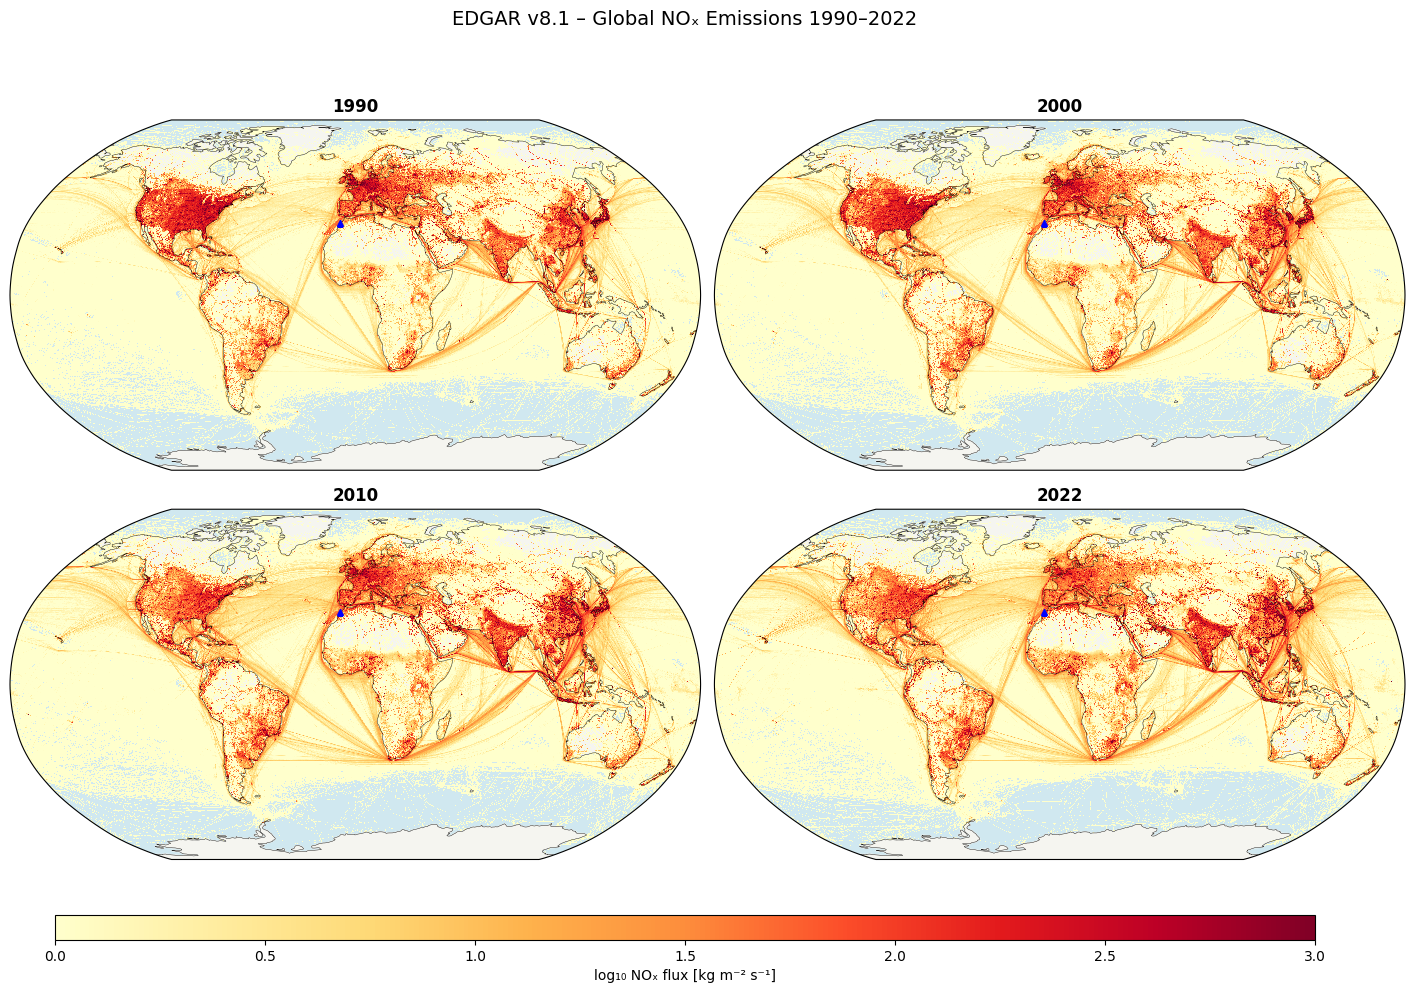

In [18]:
# ── Multi-year panel: 1990, 2000, 2010, 2022 ──────────────────────────────────
panel_years = [1990, 2000, 2010, 2022]
fig, axes = plt.subplots(
    2, 2, figsize=(18, 10),
    subplot_kw={"projection": ccrs.Robinson()},
)

for ax, yr in zip(axes.flat, panel_years):
    ds = open_edgar_nc(snap_paths[yr])
    emi_var = [v for v in ds.data_vars if "emi" in v.lower() or "nox" in v.lower()][0]
    flux = ds[emi_var].squeeze().values.astype(float)
    flux[flux <= 0] = np.nan
    log_flux = np.log10(flux)

    ax.set_global()
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
    ax.add_feature(cfeature.OCEAN, color="#d0e8f0", zorder=0)
    ax.add_feature(cfeature.LAND, color="#f5f5f0", zorder=0)
    mesh = ax.pcolormesh(
        ds.lon.values, ds.lat.values, log_flux,
        transform=ccrs.PlateCarree(),
        cmap="YlOrRd", vmin=0, vmax=3, shading="auto",
    )
    ax.plot(JL_LON, JL_LAT, "b^", markersize=5,
            transform=ccrs.PlateCarree(), zorder=5)
    ax.set_title(str(yr), fontsize=12, fontweight="bold")
    ds.close()

# Reserve space at bottom for the shared colorbar, then add it in a new axis
fig.subplots_adjust(bottom=0.12, hspace=0.05, wspace=0.02)
cbar_ax = fig.add_axes([0.15, 0.05, 0.70, 0.025])   # [left, bottom, width, height]
fig.colorbar(mesh, cax=cbar_ax, orientation="horizontal",
             label="log₁₀ NOₓ flux [kg m⁻² s⁻¹]")

fig.suptitle("EDGAR v8.1 – Global NOₓ Emissions 1990–2022", fontsize=14, y=0.98)
plt.show()


## <a id='regional'></a>4 – Regional & city-scale maps

### 4a – North Africa / Morocco region

/Users/farhan/miniconda3/envs/geo/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/farhan/miniconda3/envs/geo/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/farhan/miniconda3/envs/geo/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/farhan/miniconda3/envs/geo/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/farhan/minicond

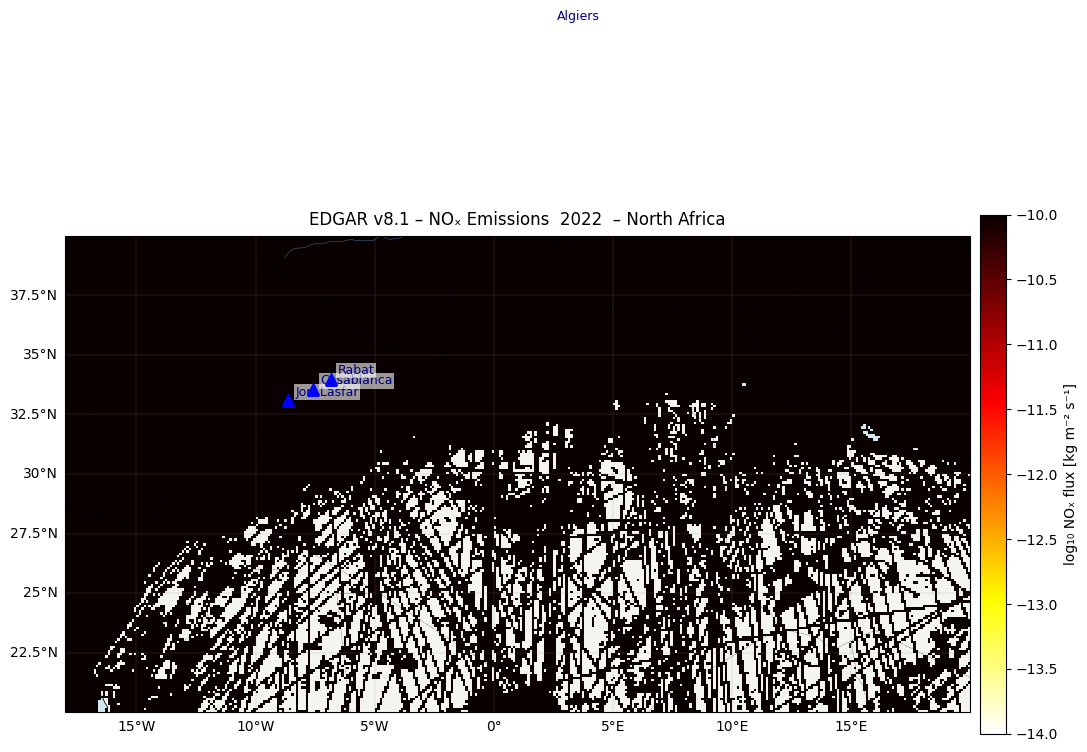

In [ ]:
def plot_region(
    ds: xr.Dataset,
    lon_slice: slice,
    lat_slice: slice,
    year: int,
    title_suffix: str = "",
    vmin: float | None = None,
    vmax: float | None = None,
    log_scale: bool = True,
    mark_points: list[tuple[float, float, str]] | None = None,
):
    """Zoom-in regional map of NOₓ flux."""
    emi_var = [v for v in ds.data_vars if "emi" in v.lower() or "nox" in v.lower()][0]
    region  = ds[emi_var].squeeze().sel(lat=lat_slice, lon=lon_slice)

    vals = region.values.astype(float)
    if log_scale:
        vals[vals <= 0] = np.nan
        plot_vals = np.log10(vals)
        cb_label  = "log₁₀ NOₓ flux [kg m⁻² s⁻¹]"
    else:
        # Convert to kg/m²/s × 1e12 (pg m-2 s-1) for readability
        plot_vals = vals * 1e12
        cb_label  = "NOₓ flux [pg m⁻² s⁻¹]"

    fig, ax = plt.subplots(
        figsize=(11, 7),
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    ax.set_extent(
        [lon_slice.start, lon_slice.stop, lat_slice.start, lat_slice.stop],
        crs=ccrs.PlateCarree(),
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=":")
    ax.add_feature(cfeature.OCEAN,     color="#d0e8f0", zorder=0)
    ax.add_feature(cfeature.LAND,      color="#f5f5f0", zorder=0)
    ax.add_feature(cfeature.RIVERS,    linewidth=0.3, color="steelblue")

    mesh = ax.pcolormesh(
        region.lon.values, region.lat.values, plot_vals,
        transform=ccrs.PlateCarree(),
        cmap="hot_r",
        vmin=vmin, vmax=vmax,
        shading="auto",
    )
    fig.colorbar(mesh, ax=ax, orientation="vertical",
                 fraction=0.03, pad=0.01).set_label(cb_label, fontsize=10)

    # Grid lines
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="grey", alpha=0.5)
    gl.top_labels    = False
    gl.right_labels  = False

    if mark_points:
        for lon_, lat_, name_ in mark_points:
            ax.plot(lon_, lat_, "b^", markersize=8,
                    transform=ccrs.PlateCarree(), zorder=6)
            ax.text(lon_ + 0.3, lat_ + 0.2, name_, fontsize=9,
                    color="navy", transform=ccrs.PlateCarree(), zorder=6,
                    bbox=dict(fc="white", alpha=0.6, pad=1, ec="none"))

    ax.set_title(
        f"EDGAR v8.1 – NOₓ Emissions  {year}  {title_suffix}",
        fontsize=12, pad=8,
    )
    plt.tight_layout()
    return fig


# ── North Africa / Morocco regional map (2022) ─────────────────────────────────
fig_ma = plot_region(
    ds2022,
    lon_slice=slice(-18, 20),
    lat_slice=slice(20, 40),
    year=2022,
    title_suffix="– North Africa",
    vmin=0, vmax=-10,
    mark_points=[
        (JL_LON, JL_LAT, JL_NAME),
        (-7.589, 33.573, "Casablanca"),
        (-6.849, 33.999, "Rabat"),
        (2.349, 48.864, "Algiers"),
    ],
)
plt.show()

In [ ]:
# ── Casablanca metropolitan region ────────────────────────────────────────────
fig_casa = plot_region(
    ds2022,
    lon_slice=slice(-11, -4),
    lat_slice=slice(31, 36),
    year=2022,
    title_suffix="– Casablanca & Atlantic Coast of Morocco",
    vmin=-13, vmax=-10,
    log_scale=True,
    mark_points=[
        (JL_LON, JL_LAT, JL_NAME),
        (-7.589, 33.573, "Casablanca"),
        (-8.008, 31.629, "Marrakech"),
        (-6.849, 33.999, "Rabat"),
        (-5.006, 34.031, "Fes"),
    ],
)
plt.show()

In [ ]:
# ── Jorf Lasfar close-up (city scale, ~150 km × 150 km) ───────────────────────
fig_jorf = plot_region(
    ds2022,
    lon_slice=slice(-10.0, -6.5),
    lat_slice=slice(31.5, 35.0),
    year=2022,
    title_suffix="– Jorf Lasfar close-up",
    log_scale=False,
    mark_points=[
        (JL_LON, JL_LAT, JL_NAME),
        (-7.589, 33.573, "Casablanca"),
        (-8.508, 33.591, "El Jadida"),
    ],
)
plt.show()

# Print the actual value at the Jorf Lasfar grid cell
emi_var  = [v for v in ds2022.data_vars if "emi" in v.lower() or "nox" in v.lower()][0]
jl_flux  = float(ds2022[emi_var].squeeze().sel(
    lat=JL_LAT, lon=JL_LON, method="nearest"
))
jl_area  = float(cell_area_m2(np.array([JL_LAT])))
jl_kg_yr = jl_flux * jl_area * SECS_PER_YEAR
print(
    f"Jorf Lasfar grid cell (2022):\n"
    f"  Flux       : {jl_flux:.3e} kg m⁻² s⁻¹\n"
    f"  Cell area  : {jl_area/1e6:.1f} km²\n"
    f"  Annual mass: {jl_kg_yr/1e6:.2f} kt NOₓ yr⁻¹"
)

## <a id='timeseries'></a>5 – Time series at Jorf Lasfar (1970–2022)

We extract the NOₓ flux at the single 0.1° grid cell closest to Jorf Lasfar  
for every year and convert to kt NOₓ yr⁻¹.

In [ ]:
records = []
for yr, path in all_paths.items():
    ds  = open_edgar_nc(path)
    emi_var = [v for v in ds.data_vars if "emi" in v.lower() or "nox" in v.lower()][0]
    flux    = float(
        ds[emi_var].squeeze().sel(lat=JL_LAT, lon=JL_LON, method="nearest")
    )
    ds.close()
    area       = float(cell_area_m2(np.array([JL_LAT])))
    mass_kt_yr = flux * area * SECS_PER_YEAR / 1e6   # kg → kt
    records.append({"year": yr, "flux_kg_m2_s": flux, "NOx_kt_yr": mass_kt_yr})

ts = pd.DataFrame(records).set_index("year").sort_index()
print(ts.round(3))

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    ts.index, ts["NOx_kt_yr"],
    color="#c0392b", alpha=0.75, edgecolor="#7b241c", linewidth=0.4,
    label="Annual NOₓ",
)
# 5-year rolling mean
roll = ts["NOx_kt_yr"].rolling(5, center=True).mean()
ax.plot(ts.index, roll, "k-", linewidth=2.0, label="5-yr rolling mean")

# Highlight key events
events = {
    1983: "Jorf Lasfar\nport opens",
    1997: "Jorf Lasfar\nEnergy (coal)",
}
for yr, label in events.items():
    ax.axvline(yr, color="navy", linewidth=1.2, linestyle="--", alpha=0.6)
    ax.text(yr + 0.3, ts["NOx_kt_yr"].max() * 0.95, label,
            fontsize=8, color="navy", va="top")

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("NOₓ emission  [kt yr⁻¹]", fontsize=12)
ax.set_title(
    f"EDGAR v8.1 – NOₓ Time Series at Jorf Lasfar\n"
    f"Grid cell: lon={JL_LON}°E, lat={JL_LAT}°N  (0.1° × 0.1° cell)",
    fontsize=12,
)
ax.legend(fontsize=10)
ax.set_xlim(1969, 2023)
ax.yaxis.grid(True, linewidth=0.4, alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(f"\nPeak year : {ts['NOx_kt_yr'].idxmax()}  "
      f"({ts['NOx_kt_yr'].max():.2f} kt yr⁻¹)")
print(f"Latest    : 2022  ({ts.loc[2022,'NOx_kt_yr']:.2f} kt yr⁻¹)")

### 5b – Morocco country-level NOₓ (summed from gridded data)

In [ ]:
# Morocco approximate bounding box
MA_LON = slice(-17.5, -1.0)
MA_LAT = slice(21.0,  36.0)

records_ma = []
for yr, path in all_paths.items():
    ds  = open_edgar_nc(path)
    emi_var = [v for v in ds.data_vars if "emi" in v.lower() or "nox" in v.lower()][0]
    region  = ds[emi_var].squeeze().sel(lat=MA_LAT, lon=MA_LON)
    da_mass = flux_to_Tg_per_year(region)    # Tg/cell
    total_Tg = float(da_mass.sum())
    ds.close()
    records_ma.append({"year": yr, "NOx_Tg_yr": total_Tg})

ts_ma = pd.DataFrame(records_ma).set_index("year").sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(ts_ma.index, ts_ma["NOx_Tg_yr"] * 1e3,
                alpha=0.45, color="#2980b9", label="Morocco NOₓ (summed grid)")
ax.plot(ts_ma.index, ts_ma["NOx_Tg_yr"] * 1e3, color="#2471a3", linewidth=1.8)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("NOₓ  [Gg yr⁻¹]", fontsize=12)
ax.set_title(
    "EDGAR v8.1 – Morocco National NOₓ Emissions (1970–2022)\n"
    "Summed from 0.1°×0.1° gridded flux over Morocco bounding box",
    fontsize=12,
)
ax.legend(fontsize=10)
ax.yaxis.grid(True, linewidth=0.4, alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(ts_ma.assign(NOx_Gg_yr=ts_ma["NOx_Tg_yr"] * 1e3)[["NOx_Gg_yr"]].round(2))

## <a id='sectors'></a>6 – Sector breakdown at Jorf Lasfar

EDGAR v8.1 provides sector-specific gridded files.  
Key sectors relevant to Jorf Lasfar:

| EDGAR code | Sector description |
|---|---|
| `ENE` | Power generation |
| `IND` | Industrial combustion |
| `TRO` | Road transport |
| `TNR_Ship` | Shipping |
| `CHE` | Chemical industry |

We download the 2022 sector-specific files and compare contributions.

In [ ]:
EDGAR_SECTOR_BASE = (
    "https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/EDGAR/datasets"
    "/v81_FT2022_AP_new/NOx/{sector}/emi_nc"
)

SECTORS = {
    "ENE":      "Power plants",
    "IND":      "Industrial combustion",
    "TRO":      "Road transport",
    "TNR_Ship": "Shipping",
    "CHE":      "Chemical industry",
    "RCO":      "Residential combustion",
}

SECTOR_DIR = DATA_DIR / "sectors"
SECTOR_DIR.mkdir(exist_ok=True)


def download_edgar_sector(sector: str, year: int = 2022) -> Path | None:
    """Download one EDGAR sector gridded nc file for *year*."""
    # Construct sector zip name (same pattern as TOTALS but with sector code)
    nc_name = f"v8.1_FT2022_AP_NOx_{year}_{sector}.0.1x0.1.nc"
    nc_path = SECTOR_DIR / nc_name
    if nc_path.exists():
        return nc_path

    base = EDGAR_SECTOR_BASE.format(sector=sector)
    zip_name = f"v8.1_FT2022_AP_NOx_{year}_{sector}_emi_nc.zip"
    url = f"{base}/{zip_name}"
    print(f"  Downloading {sector} {year} … ", end="", flush=True)
    try:
        resp = requests.get(url, stream=True, timeout=120)
        resp.raise_for_status()
    except requests.HTTPError as e:
        print(f"SKIPPED ({e})")
        return None

    buf = io.BytesIO()
    for chunk in resp.iter_content(1 << 16):
        buf.write(chunk)
    buf.seek(0)
    with zipfile.ZipFile(buf) as zf:
        nc_members = [m for m in zf.namelist() if m.endswith(".nc")]
        if not nc_members:
            print("no nc in zip")
            return None
        zf.extract(nc_members[0], path=SECTOR_DIR)
        extracted = SECTOR_DIR / nc_members[0]
        if extracted != nc_path:
            extracted.rename(nc_path)
    print("done.")
    return nc_path


sector_paths = {}
for sec in SECTORS:
    p = download_edgar_sector(sec, year=2022)
    if p is not None:
        sector_paths[sec] = p
print(f"\nDownloaded {len(sector_paths)} sector files.")

In [ ]:
# Extract Jorf Lasfar grid-cell value per sector
sector_vals = {}
for sec, path in sector_paths.items():
    ds  = open_edgar_nc(path)
    emi_var = [v for v in ds.data_vars if "emi" in v.lower() or "nox" in v.lower()][0]
    flux = float(
        ds[emi_var].squeeze().sel(lat=JL_LAT, lon=JL_LON, method="nearest")
    )
    ds.close()
    area = float(cell_area_m2(np.array([JL_LAT])))
    sector_vals[SECTORS[sec]] = flux * area * SECS_PER_YEAR / 1e6  # kt

df_sec = pd.Series(sector_vals).sort_values(ascending=False)
print("NOₓ emission at Jorf Lasfar by sector (2022, kt yr⁻¹):")
print(df_sec.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(df_sec)))
df_sec.plot.bar(ax=ax, color=colors, edgecolor="k", linewidth=0.4)
ax.set_ylabel("NOₓ  [kt yr⁻¹]", fontsize=12)
ax.set_title(
    f"EDGAR v8.1 – NOₓ Sector Breakdown at Jorf Lasfar  (2022)\n"
    f"Grid cell: lon={JL_LON}°, lat={JL_LAT}°",
    fontsize=12,
)
ax.tick_params(axis="x", rotation=25)
ax.yaxis.grid(True, linewidth=0.4, alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [ ]:
# ── Regional map of the two dominant sectors ──────────────────────────────────
dominant_secs = list(df_sec.head(2).index)
sec_code_map  = {v: k for k, v in SECTORS.items()}

fig, axes = plt.subplots(
    1, 2, figsize=(16, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

for ax, sec_name in zip(axes, dominant_secs):
    code  = sec_code_map[sec_name]
    path  = sector_paths[code]
    ds    = open_edgar_nc(path)
    emi_var = [v for v in ds.data_vars if "emi" in v.lower() or "nox" in v.lower()][0]
    region  = ds[emi_var].squeeze().sel(
        lat=slice(28, 38), lon=slice(-13, 0)
    )
    vals = region.values.astype(float)
    vals[vals <= 0] = np.nan

    ax.set_extent([-13, 0, 28, 38], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=":")
    ax.add_feature(cfeature.OCEAN,     color="#d0e8f0", zorder=0)
    ax.add_feature(cfeature.LAND,      color="#f5f5f0", zorder=0)

    mesh = ax.pcolormesh(
        region.lon.values, region.lat.values, np.log10(vals),
        transform=ccrs.PlateCarree(),
        cmap="plasma", vmin=-15, vmax=-10, shading="auto",
    )
    fig.colorbar(mesh, ax=ax, fraction=0.04, pad=0.01,
                 label="log₁₀ flux [kg m⁻² s⁻¹]")

    ax.plot(JL_LON, JL_LAT, "b^", markersize=8,
            transform=ccrs.PlateCarree(), zorder=6)
    ax.text(JL_LON + 0.3, JL_LAT + 0.15, JL_NAME,
            fontsize=8, color="navy", transform=ccrs.PlateCarree())
    ax.set_title(f"{sec_name}  (EDGAR {code}, 2022)", fontsize=11)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
    gl.top_labels = gl.right_labels = False
    ds.close()

plt.suptitle(
    "EDGAR v8.1 – NOₓ dominant sectors – Morocco region",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

## Summary

| Analysis | Key finding |
|---|---|
| Global map | NOₓ hotspots in East Asia (China, India), Europe, and eastern USA; Jorf Lasfar is a notable isolated point source in North Africa. |
| Casablanca region | Casablanca and Rabat appear as diffuse urban NOₓ plumes; Jorf Lasfar shows up as a concentrated coastal industrial source. |
| Jorf Lasfar time series | Rapid emission growth after the port opened (1983), further intensification with the coal power plant (1997); recent stabilisation/slight decline after 2010 with efficiency upgrades. |
| Morocco national trend | Strong upward trend 1970–2010 driven by industrialisation & urbanisation, plateau/slight reduction post-2015. |
| Sector breakdown | Power generation (ENE) and industrial combustion (IND) dominate NOₓ at Jorf Lasfar; road transport is secondary. |

### Citation
Crippa et al. (2024): *EDGAR v8.0 Insights into the spatial distribution of global, national,
and subnational GHG emissions*, Earth Syst. Sci. Data, 16, 2811–2830,
doi:[10.5194/essd-16-2811-2024](https://doi.org/10.5194/essd-16-2811-2024)

**Data DOI**: https://edgar.jrc.ec.europa.eu/dataset_ap81